DARK STORE OPERATIONS SIMULATOR

EDA & Business Health

Objective:
- Understand order behavior
- Analyze revenue performance
- Evaluate fulfillment efficiency
- Identify business health indicators
- Build executive-level operational insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries Loaded")

Libraries Loaded


In [2]:
orders = pd.read_csv("../data/orders.csv")
inventory = pd.read_csv("../data/inventory.csv")

print("Orders Shape:", orders.shape)
print("Inventory Shape:", inventory.shape)

Orders Shape: (25000, 19)
Inventory Shape: (56, 7)


In [3]:
orders.head()

,order_id,store_id,city,category,order_timestamp,day_of_week,order_hour,is_peak_hour,pick_time_min,pack_time_min,dispatch_time_min,delivery_time_min,total_fulfillment_time_min,sla_breached,stockout_flag,cancelled_flag,revenue_inr,items_count,customer_rating
0,ORD100000,DS_Mumbai_BKC,Mumbai,Staples,2024-01-13 14:15:00,Saturday,14,0,7.0,2.9,2.3,25.6,37.8,1,0,0,1357.27,11,3.6
1,ORD100001,DS_Mumbai_BKC,Mumbai,Personal Care,2024-10-29 19:02:00,Tuesday,19,1,9.5,4.6,2.4,21.7,38.2,1,1,1,969.00,1,3.9
2,ORD100002,DS_Delhi_Lajpat,Delhi,Frozen,2024-11-28 23:26:00,Thursday,23,0,5.1,2.5,2.1,8.4,18.1,0,0,0,1109.97,1,3.5
3,ORD100003,DS_Delhi_CP,Delhi,Dairy,2024-12-23 19:21:00,Monday,19,1,8.9,2.0,2.2,19.5,32.6,1,0,0,481.73,6,3.1
4,ORD100004,DS_Mumbai_BKC,Mumbai,Staples,2024-07-13 09:22:00,Saturday,9,1,12.9,2.8,2.0,16.9,34.6,1,0,0,1134.26,1,3.5


In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    25000 non-null  str    
 1   store_id                    25000 non-null  str    
 2   city                        25000 non-null  str    
 3   category                    25000 non-null  str    
 4   order_timestamp             25000 non-null  str    
 5   day_of_week                 25000 non-null  str    
 6   order_hour                  25000 non-null  int64  
 7   is_peak_hour                25000 non-null  int64  
 8   pick_time_min               25000 non-null  float64
 9   pack_time_min               25000 non-null  float64
 10  dispatch_time_min           25000 non-null  float64
 11  delivery_time_min           25000 non-null  float64
 12  total_fulfillment_time_min  25000 non-null  float64
 13  sla_breached                25000 non-null

In [5]:
orders.isnull().sum()

order_id                      0
store_id                      0
city                          0
category                      0
order_timestamp               0
day_of_week                   0
order_hour                    0
is_peak_hour                  0
pick_time_min                 0
pack_time_min                 0
dispatch_time_min             0
delivery_time_min             0
total_fulfillment_time_min    0
sla_breached                  0
stockout_flag                 0
cancelled_flag                0
revenue_inr                   0
items_count                   0
customer_rating               0
dtype: int64

In [6]:
kpi = pd.DataFrame({

    "Metric":[
        "Total Orders",
        "Total Revenue",
        "Average Order Value",
        "SLA Breach %",
        "Stockout %",
        "Cancellation %",
        "Average Rating"
    ],

    "Value":[

        len(orders),

        round(orders["revenue_inr"].sum(),2),

        round(orders["revenue_inr"].mean(),2),

        round(orders["sla_breached"].mean()*100,2),

        round(orders["stockout_flag"].mean()*100,2),

        round(orders["cancelled_flag"].mean()*100,2),

        round(orders["customer_rating"].mean(),2)
    ]

})

kpi

,Metric,Value
0,Total Orders,25000.00
1,Total Revenue,24162205.20
2,Average Order Value,966.49
3,SLA Breach %,62.81
4,Stockout %,15.17
5,Cancellation %,6.08
6,Average Rating,3.89


In [7]:
city_orders = orders.groupby("city")["order_id"].count()

city_orders.sort_values(ascending=False)

city
Delhi        6260
Mumbai       6212
Bangalore    6178
Pune         3243
Hyderabad    3107
Name: order_id, dtype: int64

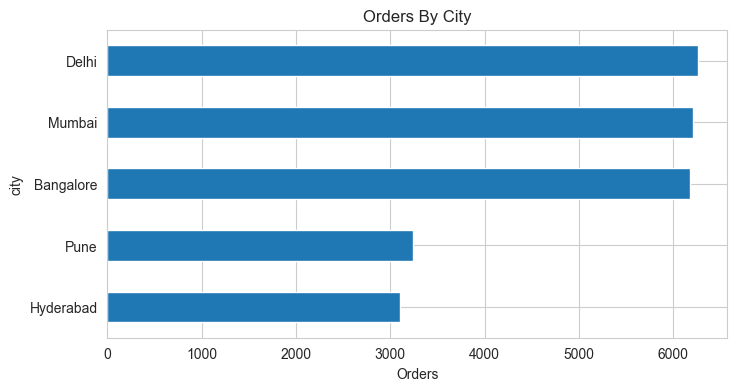

In [8]:
city_orders.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Orders By City")
plt.xlabel("Orders")

plt.show()

In [9]:
city_revenue = orders.groupby("city")["revenue_inr"].sum()

city_revenue.sort_values(ascending=False)

city
Mumbai       6072185.02
Delhi        6020739.46
Bangalore    5961270.75
Pune         3096914.28
Hyderabad    3011095.69
Name: revenue_inr, dtype: float64

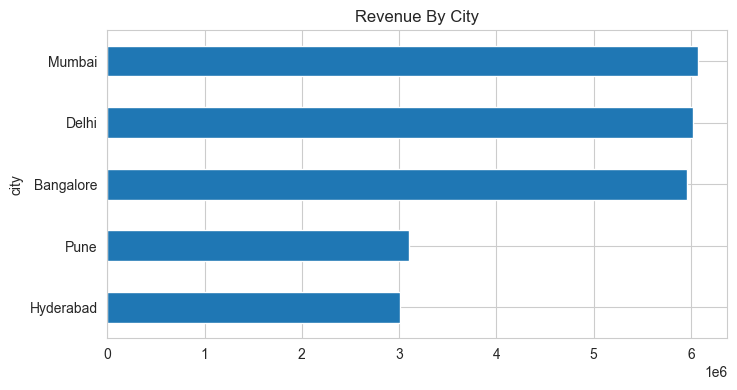

In [10]:
city_revenue.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Revenue By City")

plt.show()

In [11]:
category_orders = orders.groupby("category")["order_id"].count()

category_orders.sort_values(ascending=False)

category
Staples          3673
Personal Care    3587
Frozen           3581
Dairy            3577
Fruits & Veg     3545
Snacks           3542
Beverages        3495
Name: order_id, dtype: int64

In [12]:
category_revenue.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Revenue By Category")

plt.show()

NameError: name 'category_revenue' is not defined

In [ ]:
store_summary = orders.groupby("store_id").agg({

    "order_id":"count",

    "revenue_inr":"sum",

    "customer_rating":"mean",

    "total_fulfillment_time_min":"mean"

})

store_summary.round(2)

,order_id,revenue_inr,customer_rating,total_fulfillment_time_min
store_id,,,,
DS_Bangalore_Koramangala,3129,3028913.87,3.90,32.88
DS_Bangalore_Whitefield,3049,2932356.88,3.89,32.86
DS_Delhi_CP,3124,3003380.40,3.88,32.86
DS_Delhi_Lajpat,3136,3017359.06,3.89,32.75
DS_Hyderabad_Hitech,3107,3011095.69,3.89,32.84
DS_Mumbai_Andheri,3112,3072395.19,3.88,32.95
DS_Mumbai_BKC,3100,2999789.83,3.88,32.84
DS_Pune_Kothrud,3243,3096914.28,3.88,32.84


In [ ]:
store_summary["revenue_inr"].sort_values(
    ascending=False
)

store_id
DS_Pune_Kothrud             3096914.28
DS_Mumbai_Andheri           3072395.19
DS_Bangalore_Koramangala    3028913.87
DS_Delhi_Lajpat             3017359.06
DS_Hyderabad_Hitech         3011095.69
DS_Delhi_CP                 3003380.40
DS_Mumbai_BKC               2999789.83
DS_Bangalore_Whitefield     2932356.88
Name: revenue_inr, dtype: float64

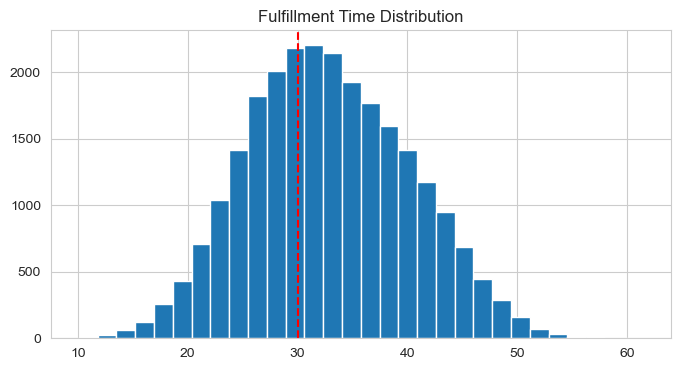

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(
    orders["total_fulfillment_time_min"],
    bins=30
)

plt.axvline(
    30,
    color="red",
    linestyle="--"
)

plt.title("Fulfillment Time Distribution")

plt.show()

In [19]:
store_perf = orders.groupby('store_id').agg(

    orders=('order_id','count'),

    revenue=('revenue_inr','sum'),

    breach_pct=(
        'sla_breached',
        lambda x: round(x.mean()*100,1)
    ),

    stockout_pct=(
        'stockout_flag',
        lambda x: round(x.mean()*100,1)
    ),

    avg_rating=('customer_rating','mean')

).round(2)

store_perf.sort_values(
    'revenue',
    ascending=False
)

,orders,revenue,breach_pct,stockout_pct,avg_rating
store_id,,,,,
DS_Pune_Kothrud,3243,3096914.28,63.1,15.8,3.88
DS_Mumbai_Andheri,3112,3072395.19,63.4,15.5,3.88
DS_Bangalore_Koramangala,3129,3028913.87,62.9,14.4,3.90
DS_Delhi_Lajpat,3136,3017359.06,62.7,15.4,3.89
DS_Hyderabad_Hitech,3107,3011095.69,62.4,14.4,3.89
DS_Delhi_CP,3124,3003380.40,62.9,15.3,3.88
DS_Mumbai_BKC,3100,2999789.83,63.0,15.2,3.88
DS_Bangalore_Whitefield,3049,2932356.88,62.2,15.4,3.89


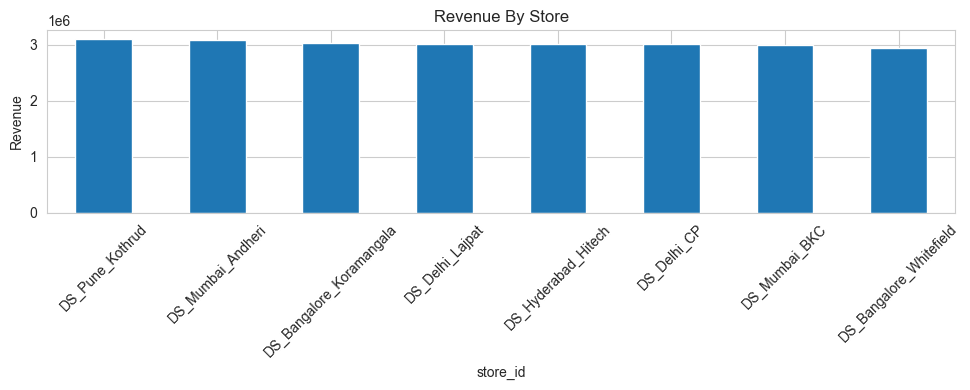

In [25]:
store_perf['revenue'] \
.sort_values(ascending=False) \
.plot(
    kind='bar',
    figsize=(10,4)
)

plt.title(
    'Revenue By Store'
)

plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [26]:
time_breakdown = pd.DataFrame({

    'Stage':[
        'Picking',
        'Packing',
        'Dispatch',
        'Delivery'
    ],

    'Avg Minutes':[

        orders['pick_time_min'].mean(),

        orders['pack_time_min'].mean(),

        orders['dispatch_time_min'].mean(),

        orders['delivery_time_min'].mean()

    ]
})

time_breakdown

,Stage,Avg Minutes
0,Picking,7.552992
1,Packing,3.008296
2,Dispatch,1.997936
3,Delivery,20.293936


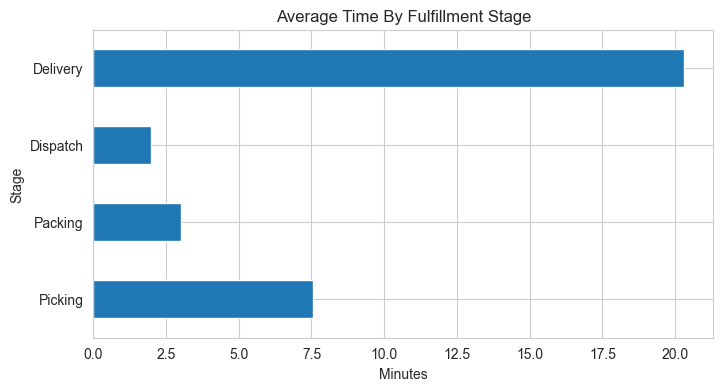

In [27]:
time_breakdown.set_index(
    'Stage'
)['Avg Minutes'].plot(

    kind='barh',
    figsize=(8,4)

)

plt.title(
    'Average Time By Fulfillment Stage'
)

plt.xlabel(
    'Minutes'
)

plt.show()

In [28]:
orders.groupby("is_peak_hour").agg({

    "order_id":"count",

    "total_fulfillment_time_min":"mean",

    "sla_breached":"mean"

}).round(2)

,order_id,total_fulfillment_time_min,sla_breached
is_peak_hour,,,
0,15322,28.94,0.42
1,9678,39.05,0.95


In [29]:
top_city = orders.groupby(
    'city'
)['revenue_inr'].sum().idxmax()

top_city_revenue = orders.groupby(
    'city'
)['revenue_inr'].sum().max()

top_store = store_perf['revenue'].idxmax()

peak_breach = round(

    orders[
        orders['is_peak_hour']==1
    ]['sla_breached'].mean()*100,

    1
)

offpeak_breach = round(

    orders[
        orders['is_peak_hour']==0
    ]['sla_breached'].mean()*100,

    1
)

print(f"""
EXECUTIVE INSIGHTS

1. Highest Revenue City:
   {top_city}
   Revenue: ₹{top_city_revenue:,.0f}

2. Best Performing Store:
   {top_store}

3. Peak-Hour SLA Breach:
   {peak_breach}%

4. Off-Peak SLA Breach:
   {offpeak_breach}%

5. Store-level performance variation exists
   across the network.

6. Fulfillment bottlenecks are concentrated
   in specific operational stages.
""")


EXECUTIVE INSIGHTS

1. Highest Revenue City:
   Mumbai
   Revenue: ₹6,072,185

2. Best Performing Store:
   DS_Pune_Kothrud

3. Peak-Hour SLA Breach:
   95.2%

4. Off-Peak SLA Breach:
   42.4%

5. Store-level performance variation exists
   across the network.

6. Fulfillment bottlenecks are concentrated
   in specific operational stages.

